In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import pandas as pd 
train_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
test_df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [6]:
train_df.shape

(1460, 81)

In [7]:
train_df["Electrical"].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [8]:
pd.set_option("display.max_columns", None)

In [9]:
missing_count = train_df.isnull().sum()
missing_percentage = (missing_count/ len(train_df))*100

missing_table = pd.DataFrame({
    "Missing Count":missing_count,
    "Missing Percentage":missing_percentage
})

missing_table = missing_table.sort_values(
    by = "Missing Percentage",
    ascending = False
)

print(missing_table.to_string())

               Missing Count  Missing Percentage
PoolQC                  1453           99.520548
MiscFeature             1406           96.301370
Alley                   1369           93.767123
Fence                   1179           80.753425
MasVnrType               872           59.726027
FireplaceQu              690           47.260274
LotFrontage              259           17.739726
GarageQual                81            5.547945
GarageFinish              81            5.547945
GarageType                81            5.547945
GarageYrBlt               81            5.547945
GarageCond                81            5.547945
BsmtFinType2              38            2.602740
BsmtExposure              38            2.602740
BsmtCond                  37            2.534247
BsmtQual                  37            2.534247
BsmtFinType1              37            2.534247
MasVnrArea                 8            0.547945
Electrical                 1            0.068493
Condition2          

In [10]:
train_df[train_df["GarageType"].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
39,40,90,RL,65.0,6040,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,4,5,1955,1955,Gable,CompShg,AsbShng,Plywood,NaN,0.0,TA,TA,PConc,NaN,NaN,NaN,NaN,0,NaN,0,0,0,GasA,TA,N,FuseP,1152,0,0,1152,0,0,2,0,2,2,Fa,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,AdjLand,82000
48,49,190,RM,33.0,4456,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,2fmCon,2Story,4,5,1920,2008,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,736,736,GasA,Gd,Y,SBrkr,736,716,0,1452,0,0,2,0,2,3,TA,8,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,102,0,0,0,NaN,NaN,NaN,0,6,2009,New,Partial,113000
78,79,90,RL,72.0,10778,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,Duplex,1Story,4,5,1968,1968,Hip,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,1768,1768,GasA,TA,N,SBrkr,1768,0,0,1768,0,0,2,0,4,2,TA,8,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,136500
88,89,50,C (all),105.0,8470,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,IDOTRR,Feedr,Feedr,1Fam,1.5Fin,3,2,1915,1982,Hip,CompShg,Plywood,Plywood,NaN,0.0,Fa,Fa,CBlock,TA,Fa,No,Unf,0,Unf,0,1013,1013,GasA,TA,N,SBrkr,1013,0,513,1526,0,0,1,0,2,1,Fa,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,156,0,0,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
89,90,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,4,5,1994,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,588,Unf,0,402,990,GasA,Ex,Y,SBrkr,990,0,0,990,1,0,1,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,123600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349,1350,70,RM,50.0,5250,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,8,5,1872,1987,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Gd,BrkTil,TA,Fa,No,LwQ,259,Unf,0,425,684,OthW,Fa,N,SBrkr,938,1215,205,2358,0,0,2,0,4,1,TA,8,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,54,20,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,122000
1407,1408,20,RL,NaN,8780,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,1985,1985,Gable,CompShg,HdBoard,Plywood,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,625,Unf,0,208,833,GasA,Ex,Y,SBrkr,833,0,0,833,1,0,1,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,0,0,0,0,0,NaN,MnPrv,NaN,0,3,2009,WD,Normal,112000
1449,1450,180,RM,21.0,1533,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,SFoyer,5,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,Gd,TA,Av,GLQ,553,Unf,0,77,630,GasA,Ex,Y,SBrkr,630,0,0,630,1,0,1,0,1,1,Ex,3,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2006,WD,Abnorml,92000
1450,1451,90,RL,60.0,9000,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,Duplex,2Story,5,5,1974,1974,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,Gd,TA,No,Unf,0,Unf,0,896,896,GasA,TA,Y,SBrkr,896,896,0,1792,0,0,2,2,4,2,TA,8,Typ,0,NaN,NaN,NaN,NaN,0,

In [11]:
train_df[train_df["BsmtQual"].isnull()][
    ["BsmtQual", "BsmtCond", "BsmtExposure",
     "BsmtFinType1", "BsmtFinType2",
     "TotalBsmtSF", "BsmtFinSF1",
     "BsmtFinSF2", "BsmtUnfSF"]
]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF
17,NaN,NaN,NaN,NaN,NaN,0,0,0,0
39,NaN,NaN,NaN,NaN,NaN,0,0,0,0
90,NaN,NaN,NaN,NaN,NaN,0,0,0,0
102,NaN,NaN,NaN,NaN,NaN,0,0,0,0
156,NaN,NaN,NaN,NaN,NaN,0,0,0,0
182,NaN,NaN,NaN,NaN,NaN,0,0,0,0
259,NaN,NaN,NaN,NaN,NaN,0,0,0,0
342,NaN,NaN,NaN,NaN,NaN,0,0,0,0
362,NaN,NaN,NaN,NaN,NaN,0,0,0,0
371,NaN,NaN,NaN,NaN,NaN,0,0,0,0


In [12]:
train_df[
    train_df["BsmtExposure"].isnull() &
    train_df["BsmtQual"].notnull()
]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
948,949,60,RL,65.0,14006,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,144.0,Gd,TA,PConc,Gd,TA,NaN,Unf,0,Unf,0,936,936,GasA,Ex,Y,SBrkr,936,840,0,1776,0,0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,2002.0,RFn,2,474,TA,TA,Y,144,96,0,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Normal,192500


In [13]:
train_df[train_df["FireplaceQu"].isnull()][["Fireplaces","FireplaceQu"]].head()

,Fireplaces,FireplaceQu
0,0,NaN
5,0,NaN
10,0,NaN
12,0,NaN
15,0,NaN


In [14]:
train_df[train_df["MasVnrType"].isnull()][["MasVnrType", "MasVnrArea"]]

,MasVnrType,MasVnrArea
1,NaN,0.0
3,NaN,0.0
5,NaN,0.0
8,NaN,0.0
9,NaN,0.0
...,...,...
1454,NaN,0.0
1455,NaN,0.0
1457,NaN,0.0
1458,NaN,0.0


In [15]:
garage_cat = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

for col in garage_cat:
    train_df[col] = train_df[col].fillna("None")

garage_num = [
    "GarageArea",
    "GarageCars",
    "GarageYrBlt"
]

for col in garage_num:
    train_df[col] = train_df[col].fillna(0)


bsmt_cat = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

no_basement = train_df["TotalBsmtSF"] == 0

for col in bsmt_cat:
    train_df.loc[no_basement,col] = train_df.loc[no_basement, col].fillna("None")

for col in bsmt_cat:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

train_df["FireplaceQu"] = train_df["FireplaceQu"].fillna("None")

train_df["PoolQC"] = train_df["PoolQC"].fillna("None")

train_df["Fence"] = train_df["Fence"].fillna("None")

train_df["Alley"] = train_df["Alley"].fillna("None")

train_df["MasVnrType"] = train_df["MasVnrType"].fillna("None")

train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(0)

train_df["LotFrontage"] = (
    train_df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
)

train_df["Electrical"] = train_df["Electrical"].fillna(train_df["Electrical"].mode()[0])


In [16]:
train_df["MiscFeature"] = train_df["MiscFeature"].fillna("None")

In [17]:

print(train_df.isnull().sum().to_string())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr

In [18]:
train_df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [19]:
train_df["SalePrice"].skew()

np.float64(1.8828757597682129)

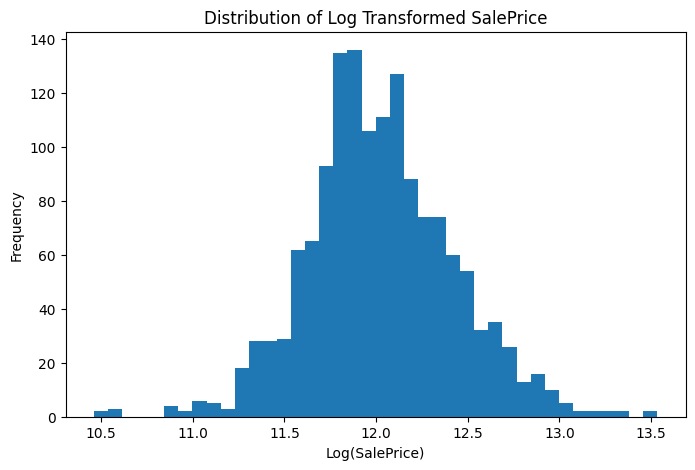

Original Skewness: 1.8828757597682129
Log Skewness: 0.12134661989685333


In [20]:
import numpy as np
import matplotlib.pyplot as plt

train_df["SalePriceLog"] = np.log1p(train_df["SalePrice"])

plt.figure(figsize=(8,5))
plt.hist(train_df["SalePriceLog"], bins=40)
plt.xlabel("Log(SalePrice)")
plt.ylabel("Frequency")
plt.title("Distribution of Log Transformed SalePrice")
plt.show()

print("Original Skewness:", train_df["SalePrice"].skew())
print("Log Skewness:", train_df["SalePriceLog"].skew())

In [21]:
numerical_features = train_df.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = train_df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:",len(numerical_features))
print("Categorical:",len(categorical_features))

Numerical: 39
Categorical: 43


In [22]:
corr = train_df[numerical_features].corr()

saleprice_corr = corr["SalePrice"].sort_values(ascending = False)

saleprice_corr

SalePrice        1.000000
SalePriceLog     0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr

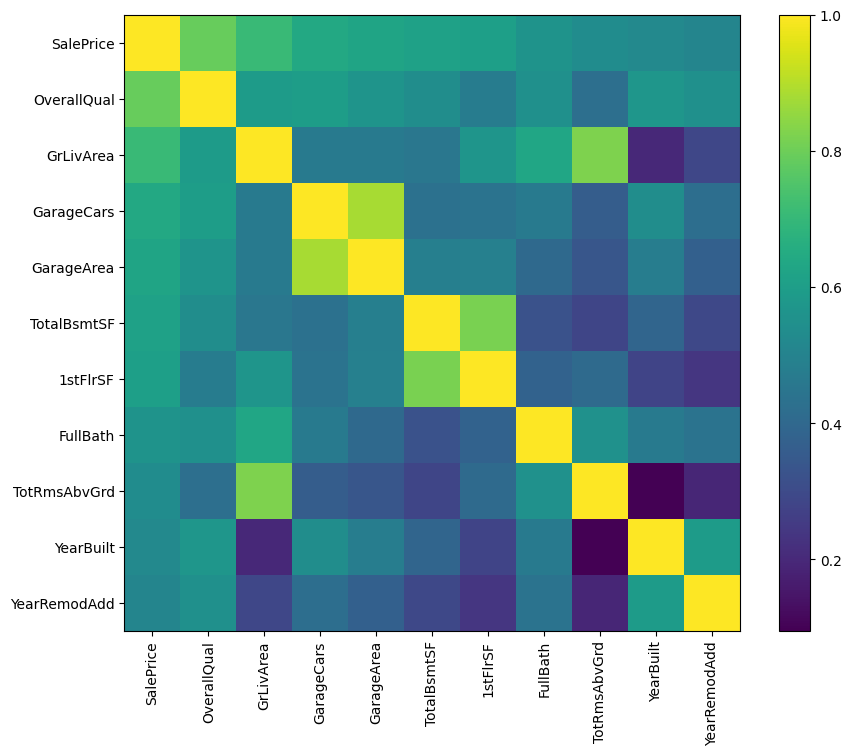

In [23]:
import matplotlib.pyplot as plt

top_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd"
]

corr_matrix = train_df[top_features].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)

plt.show()

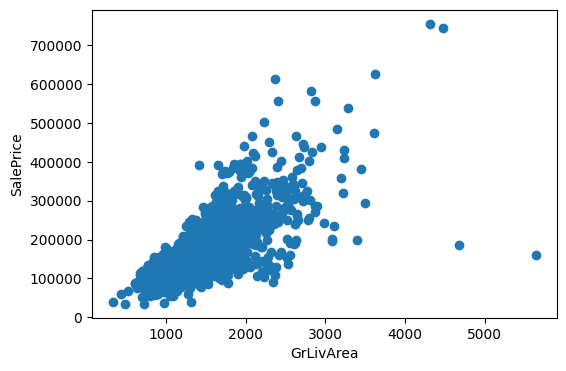

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(train_df["GrLivArea"], train_df["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [25]:
train_df[(train_df["GrLivArea"]>4000)&(train_df["SalePrice"]<300000)][["Id","GrLivArea","SalePrice","OverallQual","Neighborhood"]]



,Id,GrLivArea,SalePrice,OverallQual,Neighborhood
523,524,4676,184750,10,Edwards
1298,1299,5642,160000,10,Edwards


In [26]:
train_df = train_df.drop(train_df[(train_df["GrLivArea"] > 4000) &
        (train_df["SalePrice"] < 300000)].index)

In [27]:
skewness = (train_df[numerical_features].drop(columns = ["SalePrice","SalePriceLog","Id"]).skew().sort_values(ascending = False))
print(skewness)



MiscVal          24.460085
PoolArea         15.948945
LotArea          12.573925
3SsnPorch        10.297106
LowQualFinSF      9.004955
KitchenAbvGr      4.484883
BsmtFinSF2        4.251925
ScreenPorch       4.118929
BsmtHalfBath      4.100114
EnclosedPorch     3.087164
MasVnrArea        2.696329
OpenPorchSF       2.339829
LotFrontage       1.547767
WoodDeckSF        1.545805
MSSubClass        1.407011
GrLivArea         1.010992
BsmtUnfSF         0.920903
1stFlrSF          0.887637
2ndFlrSF          0.812957
BsmtFinSF1        0.764789
OverallCond       0.691035
HalfBath          0.680051
TotRmsAbvGrd      0.660502
Fireplaces        0.632060
BsmtFullBath      0.590358
TotalBsmtSF       0.511703
MoSold            0.215432
BedroomAbvGr      0.212325
OverallQual       0.200786
GarageArea        0.131748
YrSold            0.095420
FullBath          0.031271
GarageCars       -0.342377
YearRemodAdd     -0.501838
YearBuilt        -0.612295
GarageYrBlt      -3.866380
dtype: float64


In [28]:
skewed_features = [
    "LotArea",
    "LotFrontage",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "MasVnrArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "ScreenPorch",
    "PoolArea",
    "LowQualFinSF"
]

for col in skewed_features:
    train_df[col] = np.log1p(train_df[col])

In [29]:
train_df["TotalSF"] = (
    train_df["TotalBsmtSF"] +
    train_df["1stFlrSF"] +
    train_df["2ndFlrSF"]
)

In [30]:
train_df["HouseAge"] = train_df["YrSold"] - train_df["YearBuilt"]

In [31]:
train_df["RemodelAge"] = train_df["YrSold"] - train_df["YearRemodAdd"]

In [32]:
train_df["GarageAge"] = train_df["YrSold"] - train_df["GarageYrBlt"]

In [33]:
train_df["TotalBathrooms"] = (
    train_df["FullBath"]
    + 0.5 * train_df["HalfBath"]
    + train_df["BsmtFullBath"]
    + 0.5 * train_df["BsmtHalfBath"]
)

In [34]:
train_df["TotalPorchSF"] = (
    train_df["OpenPorchSF"]
    + train_df["EnclosedPorch"]
    + train_df["3SsnPorch"]
    + train_df["ScreenPorch"]
)

In [35]:
train_df["TotalFinishedSF"] = (
    train_df["GrLivArea"] +
    train_df["BsmtFinSF1"] +
    train_df["BsmtFinSF2"]
)

In [36]:
train_df["HasGarage"] = (train_df["GarageArea"] > 0).astype(int)

train_df["HasBasement"] = (train_df["TotalBsmtSF"] > 0).astype(int)

train_df["HasFireplace"] = (train_df["Fireplaces"] > 0).astype(int)

train_df["HasPool"] = (train_df["PoolArea"] > 0).astype(int)

train_df["Has2ndFloor"] = (train_df["2ndFlrSF"] > 0).astype(int)

In [37]:
new_features = [
    "TotalSF",
    "HouseAge",
    "RemodelAge",
    "GarageAge",
    "TotalBathrooms",
    "TotalPorchSF",
    "TotalFinishedSF",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool",
    "Has2ndFloor"
]

train_df[new_features].head()

,TotalSF,HouseAge,RemodelAge,GarageAge,TotalBathrooms,TotalPorchSF,TotalFinishedSF,HasGarage,HasBasement,HasFireplace,HasPool,Has2ndFloor
0,20.257977,5,5,5.0,3.5,4.127134,14.005864,1,1,0,0,1
1,14.282490,31,31,31.0,2.5,0.000000,14.027777,1,1,1,0,0
2,20.415959,7,6,7.0,3.5,3.761200,13.676558,1,1,1,0,1
3,20.127741,91,36,8.0,2.0,9.192991,12.828813,1,1,1,0,1
4,21.048414,8,8,8.0,3.5,4.442651,14.181919,1,1,1,0,1


In [38]:
engineered_features = [
    "TotalSF",
    "HouseAge",
    "RemodelAge",
    "GarageAge",
    "TotalBathrooms",
    "TotalPorchSF",
    "TotalFinishedSF",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool",
    "Has2ndFloor"
]

train_df[engineered_features + ["SalePrice"]].corr()["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
TotalBathrooms     0.635896
HasFireplace       0.472350
TotalSF            0.332744
HasGarage          0.236883
TotalFinishedSF    0.184038
HasBasement        0.152860
Has2ndFloor        0.137953
HasPool            0.103995
TotalPorchSF       0.070105
GarageAge         -0.261510
RemodelAge        -0.509706
HouseAge          -0.524067
Name: SalePrice, dtype: float64

In [39]:
train_df[[
    "TotalSF",
    "HouseAge",
    "RemodelAge",
    "GarageAge",
    "TotalBathrooms",
    "TotalFinishedSF"
]].skew().sort_values(ascending=False)

GarageAge          3.866329
HouseAge           0.607894
RemodelAge         0.500821
TotalBathrooms     0.246687
TotalFinishedSF    0.031795
TotalSF           -0.076484
dtype: float64

In [40]:
train_df["GarageAge"].describe()

count    1458.000000
mean      139.266804
std       453.996042
min         0.000000
25%         7.000000
50%        30.000000
75%        50.000000
max      2010.000000
Name: GarageAge, dtype: float64

In [41]:
train_df["GarageAge"].value_counts().head(15)

GarageAge
1.0     87
0.0     82
4.0     45
2.0     35
5.0     34
3.0     34
31.0    31
6.0     31
8.0     30
10.0    27
9.0     27
7.0     26
32.0    25
11.0    25
42.0    24
Name: count, dtype: int64

In [42]:
categorical_features = train_df.select_dtypes(include="object").columns.tolist()

print(f"Total categorical features: {len(categorical_features)}")
categorical_features

Total categorical features: 43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [43]:
ordinal_features = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",

    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",

    "Functional",

    "Fence",

    "LandSlope",

    "LotShape",

    "PavedDrive",

    "GarageFinish",

    "Utilities"
]

In [44]:
quality_map = {
    "None":0,
    "Po":1,
    "Fa":2,
    "TA":3,
    "Gd":4,
    "Ex":5
}

In [45]:
quality_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

for col in quality_cols:
    train_df[col] = train_df[col].map(quality_map)

In [46]:
exposure_map = {
    "None":0,
    "No":1,
    "Mn":2,
    "Av":3,
    "Gd":4
}

train_df["BsmtExposure"] = train_df["BsmtExposure"].map(exposure_map)

In [47]:
finish_map = {
    "None":0,
    "Unf":1,
    "LwQ":2,
    "Rec":3,
    "BLQ":4,
    "ALQ":5,
    "GLQ":6
}

train_df["BsmtFinType1"] = train_df["BsmtFinType1"].map(finish_map)
train_df["BsmtFinType2"] = train_df["BsmtFinType2"].map(finish_map)

In [48]:
garage_finish = {
    "None":0,
    "Unf":1,
    "RFn":2,
    "Fin":3
}

train_df["GarageFinish"] = train_df["GarageFinish"].map(garage_finish)

In [49]:
lotshape_map = {
    "IR3":0,
    "IR2":1,
    "IR1":2,
    "Reg":3
}

train_df["LotShape"] = train_df["LotShape"].map(lotshape_map)

In [50]:
paved_map = {
    "N":0,
    "P":1,
    "Y":2
}

train_df["PavedDrive"] = train_df["PavedDrive"].map(paved_map)

In [51]:
functional_map = {
    "Sal":0,
    "Sev":1,
    "Maj2":2,
    "Maj1":3,
    "Mod":4,
    "Min2":5,
    "Min1":6,
    "Typ":7
}

train_df["Functional"] = train_df["Functional"].map(functional_map)

In [52]:
nominal_features = [
    col for col in categorical_features
    if col not in ordinal_features
]

In [53]:
train_df = pd.get_dummies(
    train_df,
    columns = nominal_features,
    drop_first = True,
    dtype=int
)

In [54]:
train_df.shape

(1458, 216)

In [55]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [56]:
garage_cat = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

for col in garage_cat:
    test_df[col] = test_df[col].fillna("None")

test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(0)

test_df["GarageCars"] = test_df["GarageCars"].fillna(0)

test_df["GarageArea"] = test_df["GarageArea"].fillna(0)

In [57]:
bsmt_cat = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

for col in bsmt_cat:
    test_df[col] = test_df[col].fillna("None")

bsmt_num = [
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath"
]

for col in bsmt_num:
    test_df[col] = test_df[col].fillna(0)

In [58]:
test_df["LotFrontage"] = (
    test_df.groupby("Neighborhood")["LotFrontage"]
        .transform(lambda x: x.fillna(x.median()))
)

In [59]:
test_df["MasVnrType"] = test_df["MasVnrType"].fillna("None")

test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(0)

In [60]:
test_df["Electrical"] = test_df["Electrical"].fillna(
    test_df["Electrical"].mode()[0]
)

In [61]:
missing = test_df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC         1456
MiscFeature    1408
Alley          1352
Fence          1169
FireplaceQu     730
MSZoning          4
Functional        2
Utilities         2
Exterior1st       1
KitchenQual       1
Exterior2nd       1
SaleType          1
dtype: int64

In [62]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu"
]

for col in none_cols:
    test_df[col] = test_df[col].fillna("None")

In [63]:
mode_cols = [
    "MSZoning",
    "Functional",
    "Utilities",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "SaleType"
]

for col in mode_cols:
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

In [64]:
test_df.isnull().sum().sum()

np.int64(0)

In [65]:
skewed_features = [
    "LotArea",
    "LotFrontage",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "MasVnrArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "ScreenPorch",
    "PoolArea",
    "LowQualFinSF"
]

for col in skewed_features:
    test_df[col] = np.log1p(test_df[col])

In [66]:
test_df["TotalSF"] = (
    test_df["TotalBsmtSF"] +
    test_df["1stFlrSF"] +
    test_df["2ndFlrSF"]
)

test_df["HouseAge"] = test_df["YrSold"] - test_df["YearBuilt"]

test_df["RemodelAge"] = test_df["YrSold"] - test_df["YearRemodAdd"]

test_df["GarageAge"] = test_df["YrSold"] - test_df["GarageYrBlt"]

test_df["TotalBathrooms"] = (
    test_df["FullBath"] +
    0.5 * test_df["HalfBath"] +
    test_df["BsmtFullBath"] +
    0.5 * test_df["BsmtHalfBath"]
)

test_df["TotalPorchSF"] = (
    test_df["OpenPorchSF"] +
    test_df["EnclosedPorch"] +
    test_df["3SsnPorch"] +
    test_df["ScreenPorch"]
)

test_df["TotalFinishedSF"] = (
    test_df["GrLivArea"] +
    test_df["BsmtFinSF1"] +
    test_df["BsmtFinSF2"]
)

test_df["HasGarage"] = (test_df["GarageArea"] > 0).astype(int)
test_df["HasBasement"] = (test_df["TotalBsmtSF"] > 0).astype(int)
test_df["HasFireplace"] = (test_df["Fireplaces"] > 0).astype(int)
test_df["HasPool"] = (test_df["PoolArea"] > 0).astype(int)
test_df["Has2ndFloor"] = (test_df["2ndFlrSF"] > 0).astype(int)

In [67]:
for col in quality_cols:
    test_df[col] = test_df[col].map(quality_map)

test_df["BsmtExposure"] = test_df["BsmtExposure"].map(exposure_map)

test_df["BsmtFinType1"] = test_df["BsmtFinType1"].map(finish_map)
test_df["BsmtFinType2"] = test_df["BsmtFinType2"].map(finish_map)

test_df["GarageFinish"] = test_df["GarageFinish"].map(garage_finish)

test_df["LotShape"] = test_df["LotShape"].map(lotshape_map)

test_df["PavedDrive"] = test_df["PavedDrive"].map(paved_map)

test_df["Functional"] = test_df["Functional"].map(functional_map)

In [68]:
test_df = pd.get_dummies(
    test_df,
    columns=nominal_features,
    drop_first=True,
    dtype=int
)

In [69]:
X = train_df.drop(["Id", "SalePrice", "SalePriceLog"], axis=1)

In [70]:
X_test = test_df.drop("Id", axis=1)

In [71]:
X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [72]:
print(X.shape)
print(X_test.shape)

(1458, 213)
(1459, 213)


In [73]:
y = train_df["SalePriceLog"]
X = train_df.drop(["Id","SalePrice","SalePriceLog"],axis = 1)

In [74]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [75]:
X.select_dtypes(include="object").columns

Index(['Utilities', 'LandSlope', 'Fence'], dtype='object')

In [76]:
utilities_map = {
    "ELO": 0,
    "NoSeWa": 1,
    "NoSewr": 2,
    "AllPub": 3
}

train_df["Utilities"] = train_df["Utilities"].map(utilities_map)
test_df["Utilities"] = test_df["Utilities"].map(utilities_map)

In [77]:
landslope_map = {
    "Sev": 0,
    "Mod": 1,
    "Gtl": 2
}

train_df["LandSlope"] = train_df["LandSlope"].map(landslope_map)
test_df["LandSlope"] = test_df["LandSlope"].map(landslope_map)

In [78]:
fence_map = {
    "None": 0,
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
}

train_df["Fence"] = train_df["Fence"].map(fence_map)
test_df["Fence"] = test_df["Fence"].map(fence_map)

In [79]:
X = train_df.drop(["Id", "SalePrice", "SalePriceLog"], axis=1)
X_test = test_df.drop("Id", axis=1)

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [80]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [81]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [82]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [83]:
import numpy as np

rmse = -scores

print(rmse)
print("Mean:", rmse.mean())

[0.13327707 0.1413179  0.14401794 0.12922675 0.13897251]
Mean: 0.1373624354726608


In [84]:
rf.fit(X, y)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [85]:
predictions = rf.predict(X_test)

In [86]:
predictions = np.expm1(predictions)

In [87]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,Id,SalePrice
0,1461,125349.086238
1,1462,153069.436943
2,1463,182714.558368
3,1464,179987.591809
4,1465,193964.252873
